# Real-Time Endoscopic Tool Detection

End-to-end build of a surgical-tool detector for endoscopic video, taken from dataset conversion to an edge-style deployment:

* **Detector** – YOLO11n fine-tuned on Kvasir-Instrument (GI endoscopy, 590 frames), with a YOLOv8n baseline.
* **Validation** – single 85/15 split, **5-fold cross-validation**, and a **cross-dataset test on laparoscopic video (m2cai16-tool)**.
* **Deployment** – ONNX → TensorRT engine benchmarked with `trtexec`, a PySide6 (Qt) live panel, and a C++17 POSIX-termios relay that reports detection state over a (virtual) UART to a simulated microcontroller.
* **Regulated-style docs** – requirements with verification results (`docs/`).

| Result | Value |
|---|---|
| YOLO11n validation mAP50 / mAP50-95 (single split) | 0.937 / 0.804 |
| 5-fold cross-validation mAP50 | 0.963 ± 0.034 |
| Cross-dataset (laparoscopic m2cai16, no retraining) mAP50 | 0.167 |
| TensorRT GPU latency, batch 1 @ 640 px (3,451 runs) | mean 0.87 ms · p99 1.03 ms |

**How to read this notebook.** Cells that *show results* run on the artefacts saved from the original runs in `results/`, so the notebook renders
without the dataset. Cells that *produce* those artefacts (conversion, training, export) are included as runnable code; they need the datasets and a
CUDA GPU (runs were done on an RTX 5080) and were not re-executed here.

## 0 · Setup

In [1]:
import io, json, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Markdown, display, Image as IPyImage

RESULTS = Path("results")          # everything saved from the original runs lives here
FIG = RESULTS / "figures"

def show(path, width=1100, caption=None):
    """Display a saved result image, downscaled so the notebook stays small."""
    im = Image.open(path).convert("RGB")
    if im.width > width:
        im = im.resize((width, round(im.height * width / im.width)), Image.LANCZOS)
    buf = io.BytesIO(); im.save(buf, format="JPEG", quality=85)
    if caption:
        display(Markdown(f"*{caption}*"))
    display(IPyImage(data=buf.getvalue(), format="jpeg"))

def show_pair(left, right, titles=("", ""), width=1400, gap=12):
    """Two result images side by side (e.g. ground truth vs prediction), embedded as one JPEG."""
    ims = [Image.open(p).convert("RGB") for p in (left, right)]
    h = min(im.height for im in ims)
    ims = [im.resize((round(im.width * h / im.height), h), Image.LANCZOS) for im in ims]
    canvas = Image.new("RGB", (ims[0].width + gap + ims[1].width, h), (252, 252, 251))
    canvas.paste(ims[0], (0, 0)); canvas.paste(ims[1], (ims[0].width + gap, 0))
    if canvas.width > width:
        canvas = canvas.resize((width, round(canvas.height * width / canvas.width)), Image.LANCZOS)
    buf = io.BytesIO(); canvas.save(buf, format="JPEG", quality=85)
    if any(titles):
        display(Markdown(f"*Left: {titles[0]} · Right: {titles[1]}*"))
    display(IPyImage(data=buf.getvalue(), format="jpeg"))

# Chart style: light surface, hairline grid, text in ink colours, fixed categorical order.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "legend.frameon": False,
    "axes.prop_cycle": mpl.cycler(color=SERIES), "figure.dpi": 110, "savefig.dpi": 160,
})

# Dataset locations (only needed to re-run the pipeline cells)
KVASIR_RAW = Path(os.environ.get("KVASIR_ROOT", "data/raw/kvasir-instrument"))   # images/ + bboxes.json
M2CAI_RAW  = Path(os.environ.get("M2CAI_ROOT",  "data/raw/m2cai16-tool-locations"))
DATA_YOLO  = Path("data/yolo")
DATA_KFOLD = Path("data/kfold")
print("results available:", sorted(p.name for p in FIG.iterdir())[:5], "...")

results available: ['kfold_map.png', 'm2cai16_cross_dataset_PR_curve.png', 'tensorrt_latency.png', 'yolo11n_PR_curve.png', 'yolo11n_training_curves.png'] ...


## 1 · Dataset: Kvasir-Instrument → YOLO format

[Kvasir-Instrument](https://datasets.simula.no/kvasir-instrument/) contains 590 GI-endoscopy frames with bounding boxes around the
instruments in view. Every instrument is mapped to a single class `tool`. A seeded 85/15 split gives **502 training frames (529 boxes)**
and **88 validation frames (91 boxes)**. Source: `src/data_prep/convert_to_yolo.py`.

In [ ]:
import json, random, shutil

def convert_kvasir_to_yolo(src: Path, dst: Path, val_ratio: float = 0.15, seed: int = 42):
    """Kvasir-Instrument bbox JSON -> YOLO txt labels (normalised cx, cy, w, h) + data.yaml."""
    img_dir, ann_dir, combined = src / "images", src / "bbox", None
    if not ann_dir.exists():                      # some mirrors ship one combined JSON keyed by image stem
        candidates = list(src.glob("*.json"))
        combined = json.load(open(candidates[0])) if candidates else None
        ann_dir = src
    images = sorted(img_dir.glob("*.jpg"))
    random.seed(seed); random.shuffle(images)
    n_val = max(1, int(len(images) * val_ratio))
    splits = {"val": images[:n_val], "train": images[n_val:]}
    for split, imgs in splits.items():
        (dst / "images" / split).mkdir(parents=True, exist_ok=True)
        (dst / "labels" / split).mkdir(parents=True, exist_ok=True)
        for img_path in imgs:
            if combined is not None:
                ann = combined.get(img_path.stem)
            else:
                p = ann_dir / f"{img_path.stem}.json"
                ann = json.load(open(p)) if p.exists() else None
            if ann is None:
                continue
            w, h = Image.open(img_path).size
            lines = []
            for b in ann.get("bbox", ann.get("boxes", [])):
                cx, cy = (b["xmin"] + b["xmax"]) / 2 / w, (b["ymin"] + b["ymax"]) / 2 / h
                bw, bh = (b["xmax"] - b["xmin"]) / w, (b["ymax"] - b["ymin"]) / h
                lines.append(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
            shutil.copy(img_path, dst / "images" / split / img_path.name)
            (dst / "labels" / split / f"{img_path.stem}.txt").write_text("\n".join(lines))
    (dst / "data.yaml").write_text(f"path: {dst.resolve()}\ntrain: images/train\nval: images/val\nnames:\n  0: tool\n")
    print(f"train={len(splits['train'])} val={len(splits['val'])}")

convert_kvasir_to_yolo(KVASIR_RAW, DATA_YOLO)

## 2 · Training: YOLO11n (with a YOLOv8n baseline)

Both models start from COCO weights and are trained with identical settings: 60 epochs, 640 px, batch 16, default augmentation.
One 60-epoch run takes 85–95 s on the RTX 5080.

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")                      # -> runs/detect/train
model.train(data=str(DATA_YOLO / "data.yaml"), epochs=60, imgsz=640, batch=16, device=0)

baseline = YOLO("yolov8n.pt")                   # -> runs/detect/train-2
baseline.train(data=str(DATA_YOLO / "data.yaml"), epochs=60, imgsz=640, batch=16, device=0)

In [2]:
def final_metrics(csv):
    df = pd.read_csv(csv); df.columns = [c.strip() for c in df.columns]
    last = df.iloc[-1]
    return {"precision": last["metrics/precision(B)"], "recall": last["metrics/recall(B)"],
            "mAP50": last["metrics/mAP50(B)"], "mAP50-95": last["metrics/mAP50-95(B)"],
            "best mAP50-95 (epoch)": f'{df["metrics/mAP50-95(B)"].max():.3f} ({int(df.loc[df["metrics/mAP50-95(B)"].idxmax(), "epoch"])})',
            "train time (s)": round(last["time"], 1)}

runs = pd.DataFrame({"YOLO11n (final)": final_metrics(RESULTS / "metrics/results_yolo11n.csv"),
                     "YOLOv8n (baseline)": final_metrics(RESULTS / "metrics/results_yolov8n.csv")}).T
runs.round(3)

,precision,recall,mAP50,mAP50-95,best mAP50-95 (epoch),train time (s)
YOLO11n (final),0.97436,0.87912,0.93709,0.80403,0.810 (47),94.7
YOLOv8n (baseline),0.91165,0.92308,0.92946,0.81847,0.833 (49),84.5


Both nano models land within a point of each other: YOLO11n has higher precision and mAP50, YOLOv8n slightly higher recall and mAP50-95.
With only 88 validation frames the gap is inside the noise, which is exactly why section 3 re-estimates the score with k-fold cross-validation.

*YOLO11n training/validation losses and metrics over 60 epochs.*

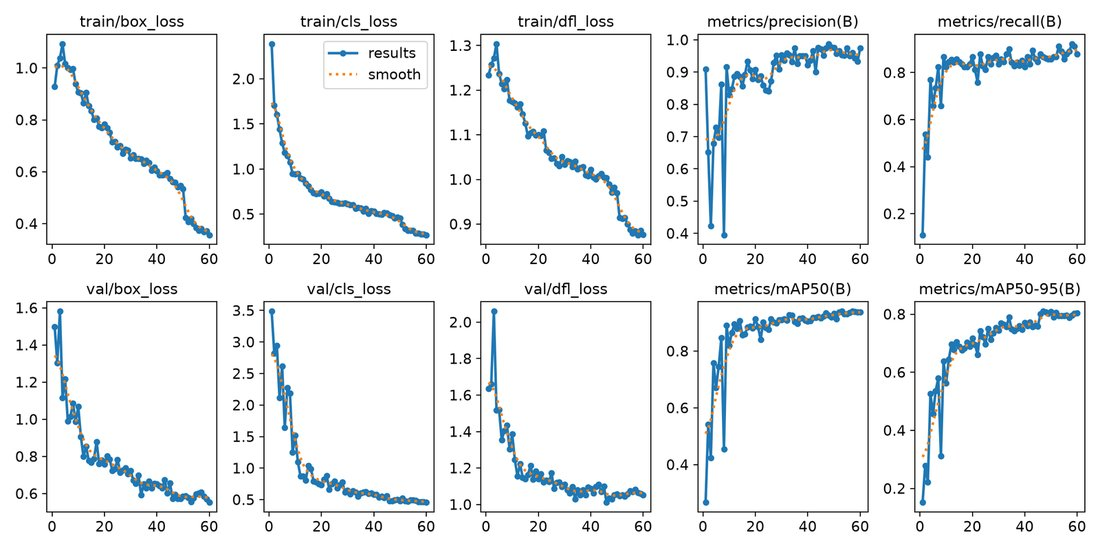

In [3]:
show(FIG / "yolo11n_training_curves.png", caption="YOLO11n training/validation losses and metrics over 60 epochs.")

*Precision–recall on the 88 validation frames.*

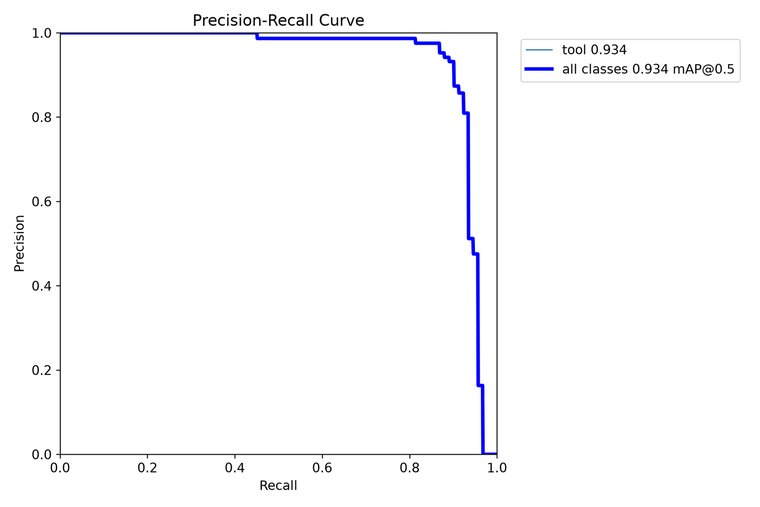

In [4]:
show(FIG / "yolo11n_PR_curve.png", width=760, caption="Precision–recall on the 88 validation frames.")

Three random validation frames, one image each. Ground truth is white and predictions are orange at the GUI's 0.4 threshold (`src/analysis/render_examples.py`):

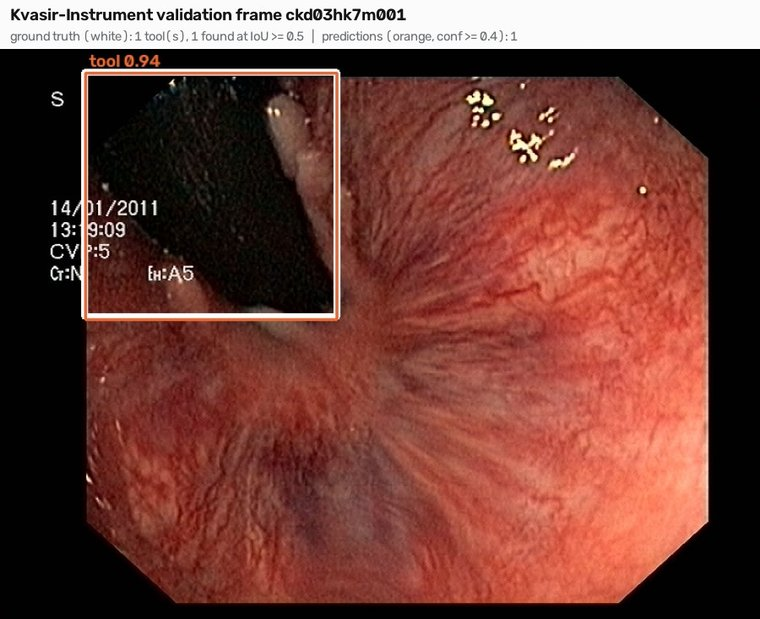

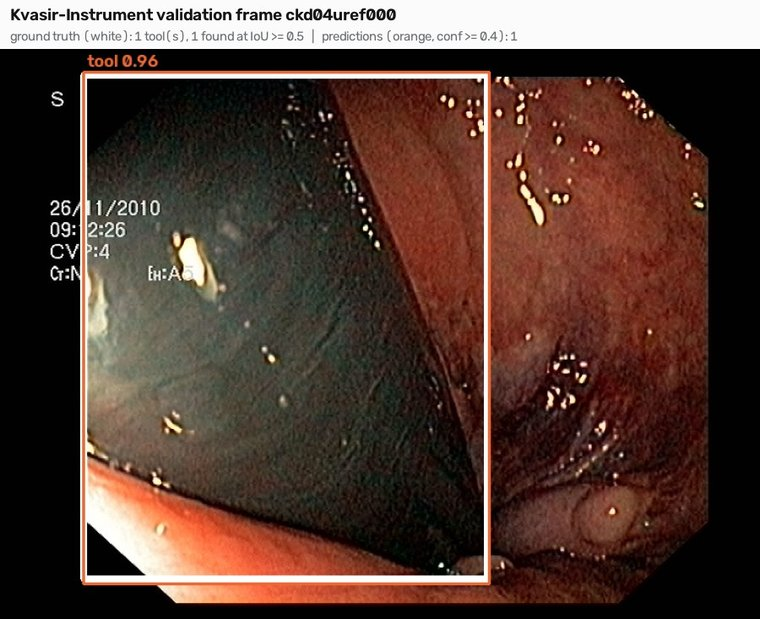

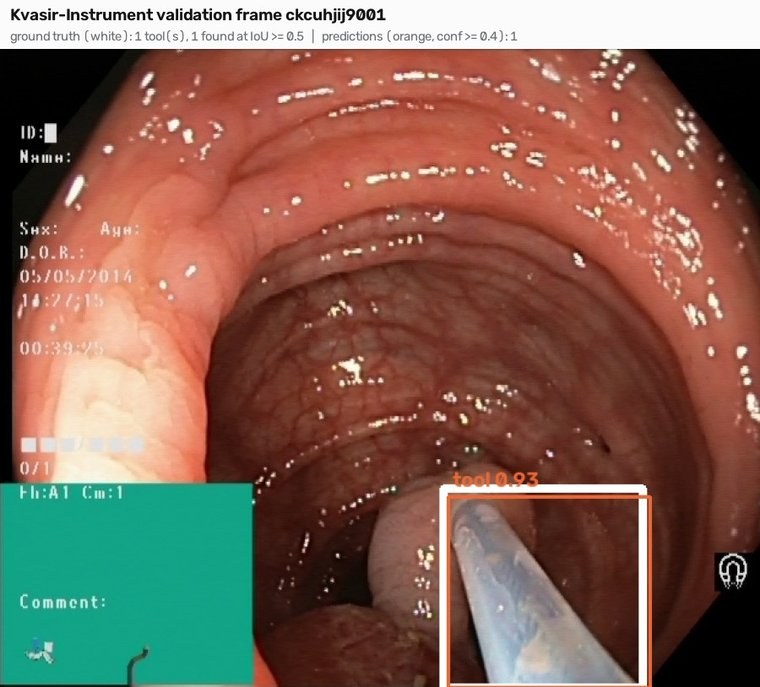

In [5]:
for i in (1, 2, 3):
    show(RESULTS / "examples" / f"in_domain_{i}.jpg", width=760)

## 3 · 5-fold cross-validation

A single 88-frame validation split can be lucky or unlucky. All 590 frames are pooled and re-split into five disjoint folds
(`src/data_prep/kfold_split.py`); YOLO11n is retrained on each fold with the same recipe (`src/data_prep/run_kfold.py`).

In [ ]:
def kfold_split(src: Path, dst: Path, k: int = 5, seed: int = 42):
    imgs = list((src / "images/train").glob("*.jpg")) + list((src / "images/val").glob("*.jpg"))
    random.seed(seed); random.shuffle(imgs)
    size = len(imgs) // k
    folds = [imgs[i * size:(i + 1) * size] for i in range(k)]
    folds[-1].extend(imgs[k * size:])
    def label_for(img):
        for s in ("train", "val"):
            p = src / "labels" / s / f"{img.stem}.txt"
            if p.exists():
                return p
    for i in range(k):
        out = dst / f"fold{i}"
        for split, members in (("val", folds[i]), ("train", [x for j, f in enumerate(folds) if j != i for x in f])):
            (out / "images" / split).mkdir(parents=True, exist_ok=True); (out / "labels" / split).mkdir(parents=True, exist_ok=True)
            for img in members:
                shutil.copy(img, out / "images" / split / img.name)
                if (lbl := label_for(img)):
                    shutil.copy(lbl, out / "labels" / split / lbl.name)
        (out / "data.yaml").write_text(f"path: {out.resolve()}\ntrain: images/train\nval: images/val\nnames:\n  0: tool\n")

kfold_split(DATA_YOLO, DATA_KFOLD)
for i in range(5):
    m = YOLO("yolo11n.pt")
    m.train(data=str(DATA_KFOLD / f"fold{i}/data.yaml"), epochs=60, imgsz=640, device=0, project="runs/kfold", name=f"fold{i}")

In [6]:
rows = []
for i in range(5):
    df = pd.read_csv(RESULTS / f"metrics/kfold/fold{i}_results.csv"); df.columns = [c.strip() for c in df.columns]
    last = df.iloc[-1]
    rows.append({"fold": i, "precision": last["metrics/precision(B)"], "recall": last["metrics/recall(B)"],
                 "mAP50": last["metrics/mAP50(B)"], "mAP50-95": last["metrics/mAP50-95(B)"]})
kfold = pd.DataFrame(rows).set_index("fold")
summary = kfold.agg(["mean", "std"]).rename(index={"std": "std (pop.)"})
summary.loc["std (pop.)"] = kfold.std(ddof=0)
kfold_table = pd.concat([kfold, summary]).round(3)
kfold_table.to_csv(RESULTS / "metrics/kfold_summary.csv")
kfold_table

,precision,recall,mAP50,mAP50-95
0,0.984,0.983,0.993,0.889
1,0.955,0.837,0.903,0.793
2,0.991,0.940,0.979,0.870
3,0.985,0.967,0.989,0.896
4,0.914,0.934,0.948,0.830
mean,0.966,0.932,0.963,0.856
std (pop.),0.029,0.051,0.034,0.039


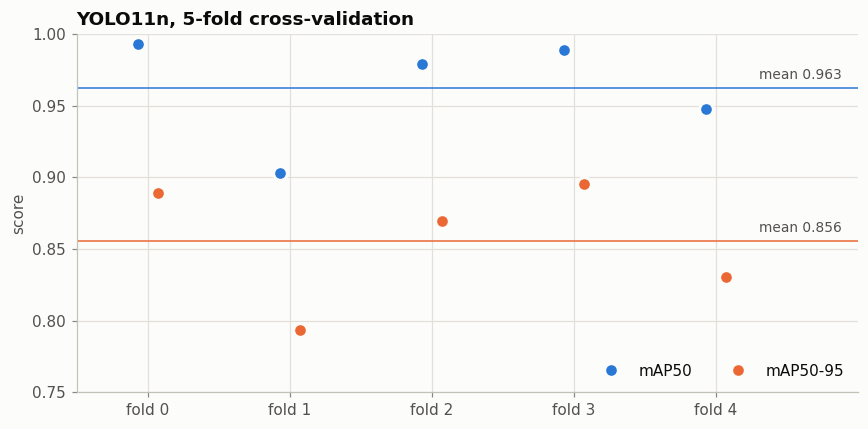

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(5)
for col, color, dx in zip(["mAP50", "mAP50-95"], SERIES, (-0.07, 0.07)):
    ax.plot(x + dx, kfold[col], "o", ms=9, color=color, mec="#fcfcfb", mew=2, ls="none", label=col)
    mean = kfold[col].mean()
    ax.axhline(mean, color=color, lw=1)
    ax.text(4.3, mean + 0.004, f"mean {mean:.3f}", va="bottom", fontsize=9, color=INK2)
ax.set_xticks(x, [f"fold {i}" for i in x]); ax.set_xlim(-0.5, 5.0); ax.set_ylim(0.75, 1.0)
ax.set_ylabel("score"); ax.set_title("YOLO11n, 5-fold cross-validation")
ax.legend(loc="lower right", ncol=2)
plt.tight_layout(); fig.savefig(FIG / "kfold_map.png"); plt.show()

Cross-validated **mAP50 = 0.963 ± 0.034** (mAP50-95 = 0.856 ± 0.039). Fold 1 is the hardest (recall 0.84), so the spread is driven by which
difficult frames land in the validation fold. The single-split number (0.937) sits inside that band.

## 4 · Cross-dataset generalisation: laparoscopic surgery (m2cai16-tool)

Kvasir frames come from flexible GI endoscopy. To test robustness to a new domain, the Kvasir-trained detector is evaluated **without any
retraining** on [m2cai16-tool-locations](https://ai.stanford.edu/~syyeung/tooldetection.html): **2,811 laparoscopic cholecystectomy frames,
3,929 boxes**, with all 7 tool classes merged into `tool` (`src/data_prep/convert_m2cai16_to_yolo.py`, Pascal-VOC XML → YOLO).

In [ ]:
import xml.etree.ElementTree as ET

def convert_m2cai16(src: Path, dst: Path):
    (dst / "images").mkdir(parents=True, exist_ok=True); (dst / "labels").mkdir(parents=True, exist_ok=True)
    for xml_path in sorted((src / "Annotations").glob("*.xml")):
        root = ET.parse(xml_path).getroot()
        img = src / "JPEGImages" / root.find("filename").text
        if not img.exists():
            continue
        W, H = float(root.find("size/width").text), float(root.find("size/height").text)
        lines = []
        for obj in root.findall("object"):
            b = obj.find("bndbox"); x1, y1, x2, y2 = (float(b.find(k).text) for k in ("xmin", "ymin", "xmax", "ymax"))
            lines.append(f"0 {(x1 + x2) / 2 / W:.6f} {(y1 + y2) / 2 / H:.6f} {(x2 - x1) / W:.6f} {(y2 - y1) / H:.6f}")
        if lines:
            shutil.copy(img, dst / "images" / img.name)
            (dst / "labels" / f"{img.stem}.txt").write_text("\n".join(lines))
    (dst / "data.yaml").write_text(f"path: {dst.resolve()}\nval: images\nnames:\n  0: tool\n")

convert_m2cai16(M2CAI_RAW, Path("data/m2cai16_yolo"))
YOLO("runs/detect/train/weights/best.pt").val(data="data/m2cai16_yolo/data.yaml")

*Precision–recall on 2,811 m2cai16 frames: mAP50 = 0.167.*

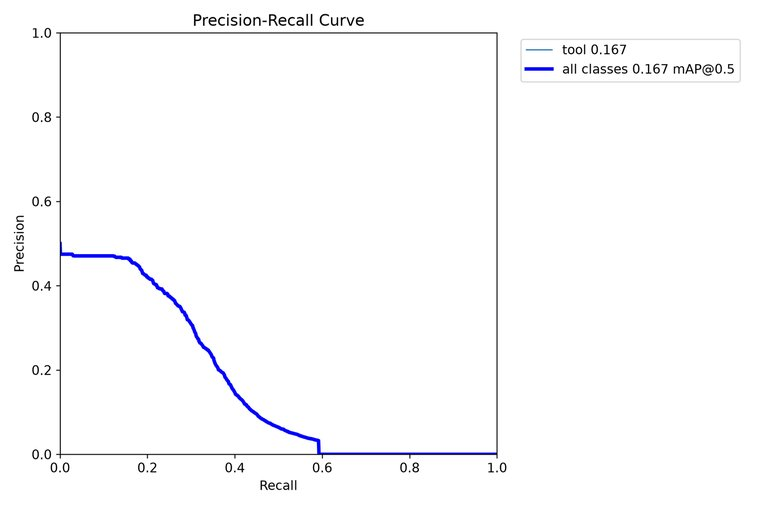

In [8]:
show(FIG / "m2cai16_cross_dataset_PR_curve.png", width=760, caption="Precision–recall on 2,811 m2cai16 frames: mAP50 = 0.167.")

Three random m2cai16 frames, one image each (white: ground truth, orange: predictions at confidence 0.4):

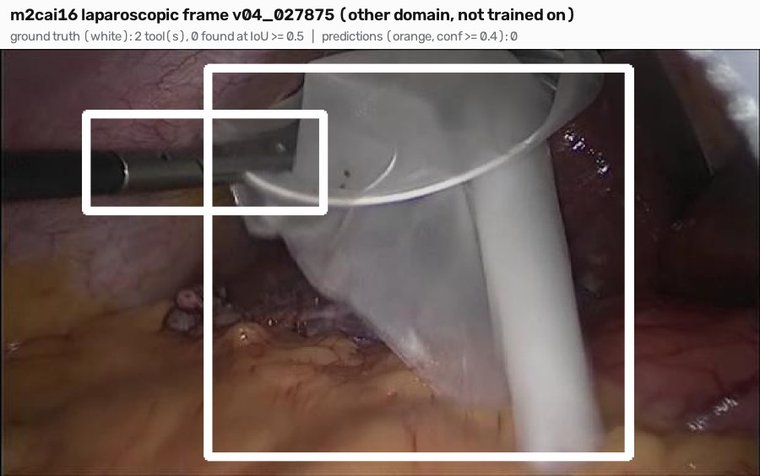

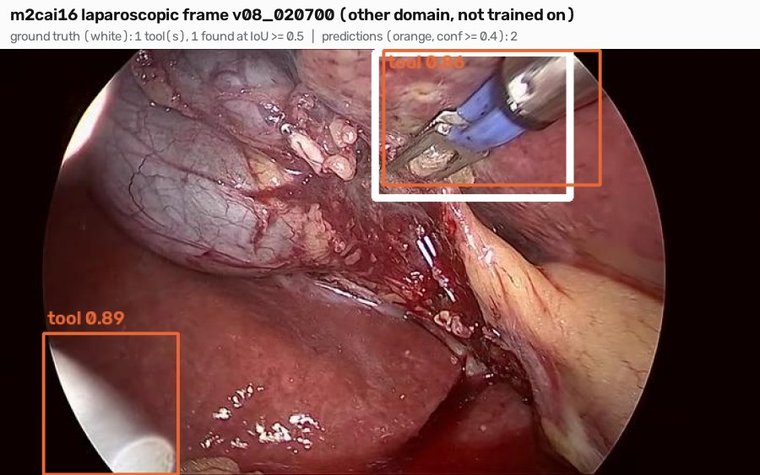

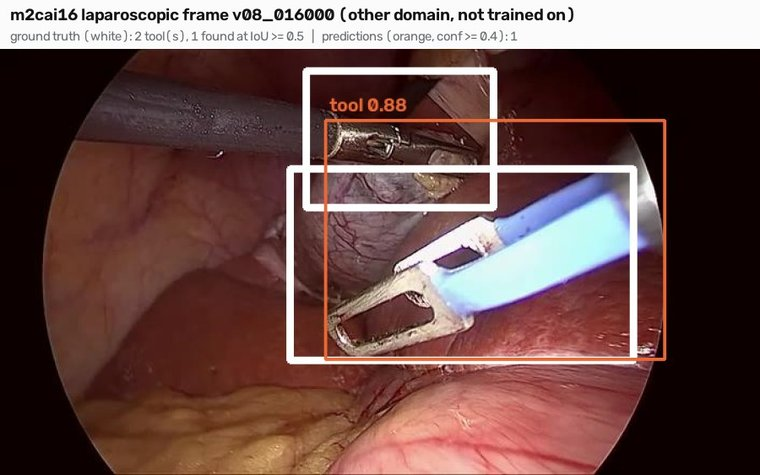

In [9]:
for i in (1, 2, 3):
    show(RESULTS / "examples" / f"cross_dataset_{i}.jpg", width=760)

**mAP50 collapses from 0.96 to 0.17.** Recall never exceeds ~0.6 and precision starts below 0.5. In the three frames above, the model finds 2 of
the 5 laparoscopic instruments and adds one extra box. The in-domain score therefore says little about performance on a different procedure. The fixes are training data that covers the target
domain (mixing m2cai16 into training, or fine-tuning on a small labelled subset) and augmentation for the circular vignette and specular highlights.

## 5 · Failure analysis

`src/analysis/failure_gallery.py` runs the model over the validation frames at a low threshold (0.1), ranks frames by their *least*
confident detection (frames with no detection rank first) and tiles the worst ones into a gallery.

In [ ]:
import cv2

def failure_gallery(model_path, images_dir: Path, out_path: Path, n=9, cols=3, tile=300):
    model = YOLO(model_path)
    scored = []
    for p in sorted(images_dir.glob("*.jpg")):
        r = model.predict(str(p), conf=0.1, verbose=False)[0]
        scored.append((p, 0.0 if len(r.boxes) == 0 else float(r.boxes.conf.min()), r))
    scored.sort(key=lambda s: s[1])
    tiles = []
    for p, c, r in scored[:n]:
        im = cv2.resize(r.plot(), (tile, tile))
        cv2.putText(im, f"{p.name} min_conf={c:.2f}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
        tiles.append(im)
    tiles += [np.zeros((tile, tile, 3), np.uint8)] * (-len(tiles) % cols)
    cv2.imwrite(str(out_path), np.vstack([np.hstack(tiles[i:i + cols]) for i in range(0, len(tiles), cols)]))

failure_gallery("runs/detect/train/weights/best.pt", DATA_YOLO / "images/val", FIG / "failure_gallery.jpg")

The three least-confident frames, one image each (`src/analysis/render_examples.py` uses the same ranking; predictions shown down to confidence 0.1):

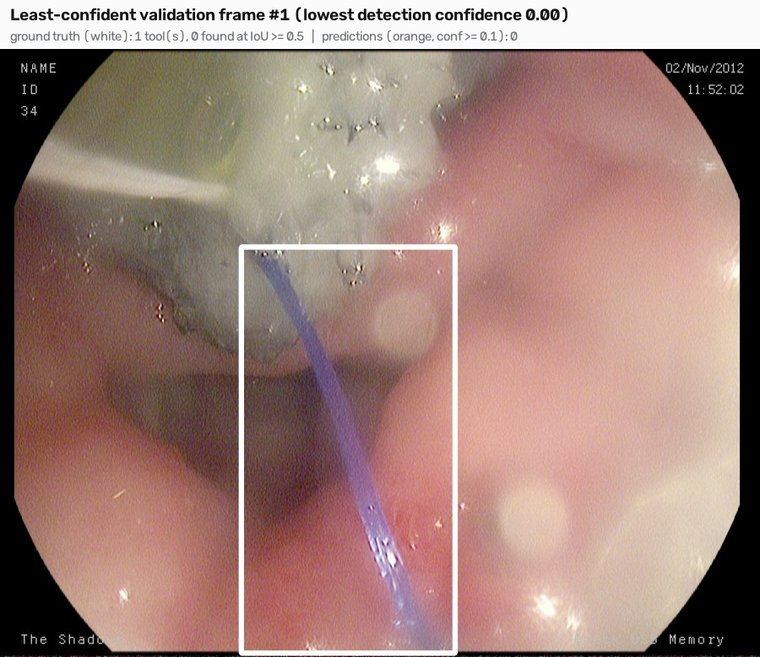

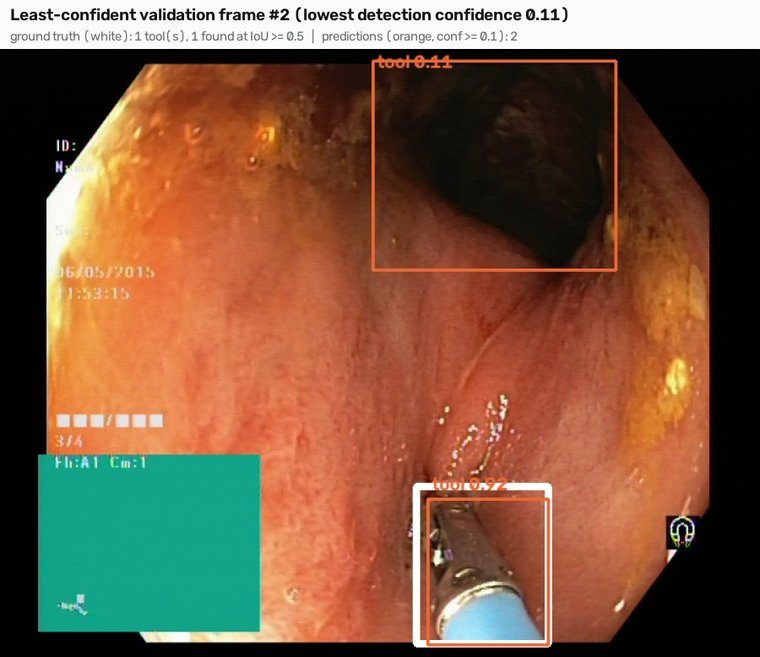

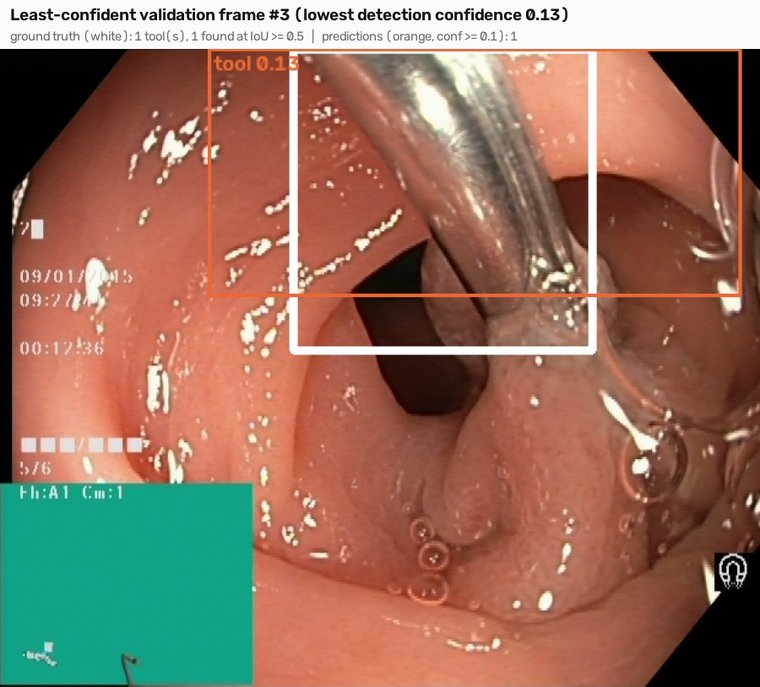

In [10]:
for i in (1, 2, 3):
    show(RESULTS / "examples" / f"failure_{i}.jpg", width=760)

1. A thin guidewire in an over-exposed view gets no detection at all.
2. The tool is found at 0.92, but a second box at 0.11 lands on a dark area of the lumen.
3. The tool is found, but only at 0.13 confidence, so at the GUI's 0.4 threshold it would be missed.

## 6 · Edge deployment: ONNX → TensorRT and latency

The best checkpoint is exported to ONNX (opset 17, simplified) and compiled into a TensorRT engine with `trtexec`.
The graph is FP32 and TensorRT 11 builds strongly-typed networks, so the engine runs in FP32; an FP16 export is the obvious next speed-up.
`trtexec --exportTimes` records every iteration, and `src/analysis/latency_report.py` turns that into a tail-latency report. For a real-time
device claim, p99 matters more than the mean.

In [ ]:
import subprocess
YOLO("runs/detect/train/weights/best.pt").export(format="onnx", opset=17, simplify=True)
subprocess.run(["trtexec", "--onnx=runs/detect/train/weights/best.onnx", "--saveEngine=tool_detector.engine"], check=True)
subprocess.run(["trtexec", "--loadEngine=tool_detector.engine", "--iterations=1000", "--avgRuns=100",
                "--exportTimes=results/metrics/tensorrt_latency_timings.json"], check=True)
# summary: python src/analysis/latency_report.py --file results/metrics/tensorrt_latency_timings.json

In [11]:
timings = json.load(open(RESULTS / "metrics/tensorrt_latency_timings.json"))
lat = np.array([t["latencyMs"] for t in timings])
pct = {"iterations": len(lat), "mean": lat.mean(), "p50": np.percentile(lat, 50), "p90": np.percentile(lat, 90),
       "p95": np.percentile(lat, 95), "p99": np.percentile(lat, 99), "p99.9": np.percentile(lat, 99.9), "max": lat.max()}
latency = pd.Series(pct, name="GPU latency (ms)").round(3)
latency.to_frame().T

,iterations,mean,p50,p90,p95,p99,p99.9,max
GPU latency (ms),3451.0,0.869,0.845,0.958,0.976,1.033,1.051,1.088


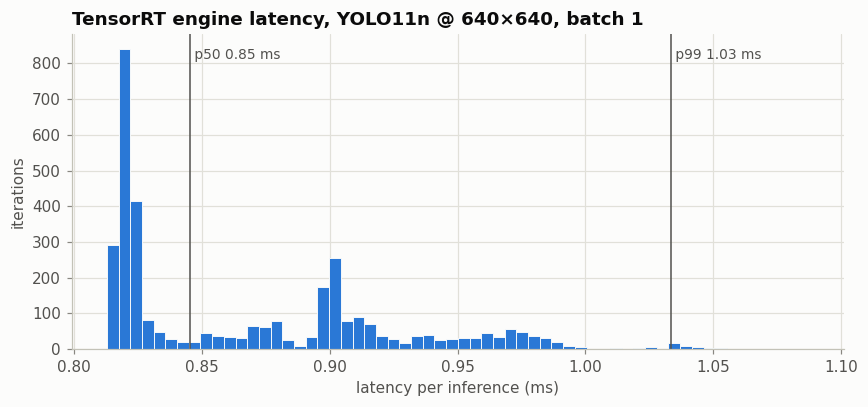

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(lat, bins=60, color=SERIES[0], edgecolor="#fcfcfb", linewidth=0.6)
for q, label in [(pct["p50"], "p50"), (pct["p99"], "p99")]:
    ax.axvline(q, color=INK2, lw=1)
    ax.text(q, ax.get_ylim()[1] * 0.92, f" {label} {q:.2f} ms", fontsize=9, color=INK2)
ax.set_xlabel("latency per inference (ms)"); ax.set_ylabel("iterations")
ax.set_title("TensorRT engine latency, YOLO11n @ 640×640, batch 1")
plt.tight_layout(); fig.savefig(FIG / "tensorrt_latency.png"); plt.show()

Every one of 3,451 iterations finished in under 1.1 ms (p99 1.03 ms), so the neural network is not the bottleneck for a 30–60 fps video feed.
These figures are GPU compute only: `trtexec` excludes image capture, pre-processing and drawing.

## 7 · Real-time system: Qt panel → status file → C++ UART relay → MCU

```
frames ─► gui/viewer.py (PySide6 + YOLO, conf 0.4) ─► status.txt ─► cpp/status_relay (C++17, termios 115200 8N1) ─► /dev/pts/N ─► uart_sim/serial_reader.py
          "TOOL DETECTED" / "CLEAR" panel            TOOL_DETECTED|CLEAR     sends "$STATE*\n" only on state change     (socat pair)      simulated microcontroller
```

* **`src/gui/viewer.py`** plays frames at about 12 fps, runs the detector, draws boxes and shows a device-style status bar. On every frame it writes the state to `status.txt`.
* **`cpp/status_relay/main.cpp`** configures the serial port directly with POSIX `termios` (raw mode, 8N1, 115200 baud, no flow control), watches the status file,
  and writes a framed message `$TOOL_DETECTED*\n` / `$CLEAR*\n` only when the state changes. There is no third-party serial library.
  `src/uart_sim/serial_writer.py` is the equivalent relay in Python.
* **`src/uart_sim/serial_reader.py`** plays the firmware side: it reads bytes, reassembles lines and accepts only well-formed `$...*` frames.
* The two ends are joined by a `socat` virtual serial pair, which is the usual way to test a serial protocol before hardware exists.

```bash
socat -d -d pty,raw,echo=0 pty,raw,echo=0            # prints e.g. /dev/pts/3 and /dev/pts/4
python src/gui/viewer.py data/yolo/images/val runs/detect/train/weights/best.pt status.txt
./cpp/status_relay/build/status_relay status.txt /dev/pts/3
python src/uart_sim/serial_reader.py /dev/pts/4
```

## 8 · Verification against requirements

`docs/requirements.md` and `docs/test_plan.md` follow a regulated-development template. Measured results so far:

| Req. | Requirement | Evidence | Status |
|---|---|---|---|
| REQ-01 | Detect tools with confidence ≥ 0.4; mAP50 ≥ 0.70 | mAP50 0.937 (split), 0.963 ± 0.034 (5-fold) | **Pass** (in-domain) |
| REQ-02 | Report detection status within 100 ms | TensorRT GPU p95 0.98 ms; end-to-end loop not yet timed | **Partial** |
| REQ-03 | Live display with overlays | `viewer.py` implemented; 2-minute soak test not recorded | Implemented, not verified |
| REQ-04 | Status over UART with a defined format | `$STATE*\n` framing, C++ + Python relays, socat test harness | Implemented, not verified |
| REQ-05 | Timestamped log of detection events | status file is overwritten, no log yet | **Open** |

## 9 · Limitations and next steps

* **Domain shift is the main risk.** The cross-dataset mAP50 of 0.17 shows the model is specific to GI endoscopy. Training on mixed data is the next experiment.
* **FP16 / INT8 engines** were not built. An FP16 ONNX export (or INT8 with calibration) would further cut latency and memory.
* **End-to-end latency** (capture → decision → UART byte) should be measured to close REQ-02, and REQ-05 needs an append-only timestamped event log.
* The GUI runs the PyTorch model. Loading the TensorRT engine there would make the demo match the benchmarked path.